# Objective 1: Goodness Function Optimization

This notebook evaluates multiple Forward-Forward goodness functions on supervised MNIST.
We include quick smoke tests and a full sweep configuration.

In [1]:
import importlib
import sys
from pathlib import Path

import pandas as pd
import torch

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import ff_research.experiments as experiments
import ff_research.utils as utils

importlib.reload(utils)
importlib.reload(experiments)

from ff_research.experiments import run_goodness_sweep
from ff_research.utils import seed_everything

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [2]:
seed_everything(42)

In [3]:
goodness_candidates = [
    "sum_sq",
    "neg_sum_sq",
    "sum_abs",
    "neg_sum_abs",
    "sum_linear",
    "neg_sum_linear",
    "mean_sq",
    "mean_abs",
    "log1p_sum_sq",
    "sqrt_sum_sq",
    "sum_softplus",
    "sum_huber_like",
    "pnorm_1_5",
    "pnorm_3",
]
len(goodness_candidates)

14

In [4]:
# Quick verification run before large sweeps
smoke_rows = run_goodness_sweep(
    goodness_names=goodness_candidates[:3],
    activation_name="relu",
    hidden_dims=(256, 256),
    epochs=1,
    batch_size=128,
    train_subset=3000,
    test_subset=1000,
    max_train_batches=8,
    max_eval_batches=3,
    device=device,
    seed=42,
)
pd.DataFrame(smoke_rows).sort_values("test_error")

,goodness,activation,train_loss,test_error,test_accuracy
1,neg_sum_sq,relu,1.964600,0.796875,0.203125
0,sum_sq,relu,1.965020,0.825521,0.174479
2,sum_abs,relu,3.860217,0.906250,0.093750


In [5]:
# Full Objective 1 sweep (runtime depends on hardware)
full_rows = run_goodness_sweep(
    goodness_names=goodness_candidates,
    activation_name="relu",
    hidden_dims=(512, 512, 512),
    epochs=10,
    batch_size=128,
    train_subset=30000,
    test_subset=10000,
    max_train_batches=None,
    max_eval_batches=None,
    device=device,
    seed=42,
)
obj1_results = pd.DataFrame(full_rows).sort_values("test_error").reset_index(drop=True)
obj1_results

,goodness,activation,train_loss,test_error,test_accuracy
0,pnorm_3,relu,0.506840,0.0446,0.9554
1,sum_huber_like,relu,0.915776,0.0601,0.9399
2,sum_sq,relu,0.557461,0.0737,0.9263
3,neg_sum_sq,relu,0.451928,0.0741,0.9259
4,log1p_sum_sq,relu,0.648728,0.0777,0.9223
5,sqrt_sum_sq,relu,0.673295,0.0941,0.9059
6,mean_sq,relu,1.157837,0.0988,0.9012
7,mean_abs,relu,1.306145,0.1519,0.8481
8,neg_sum_abs,relu,1.053865,0.2035,0.7965
9,neg_sum_linear,relu,1.110900,0.2341,0.7659


In [6]:
obj1_results.to_csv(ROOT / "results_objective1_goodness.csv", index=False)
obj1_results.head(10)

,goodness,activation,train_loss,test_error,test_accuracy
0,pnorm_3,relu,0.506840,0.0446,0.9554
1,sum_huber_like,relu,0.915776,0.0601,0.9399
2,sum_sq,relu,0.557461,0.0737,0.9263
3,neg_sum_sq,relu,0.451928,0.0741,0.9259
4,log1p_sum_sq,relu,0.648728,0.0777,0.9223
5,sqrt_sum_sq,relu,0.673295,0.0941,0.9059
6,mean_sq,relu,1.157837,0.0988,0.9012
7,mean_abs,relu,1.306145,0.1519,0.8481
8,neg_sum_abs,relu,1.053865,0.2035,0.7965
9,neg_sum_linear,relu,1.110900,0.2341,0.7659


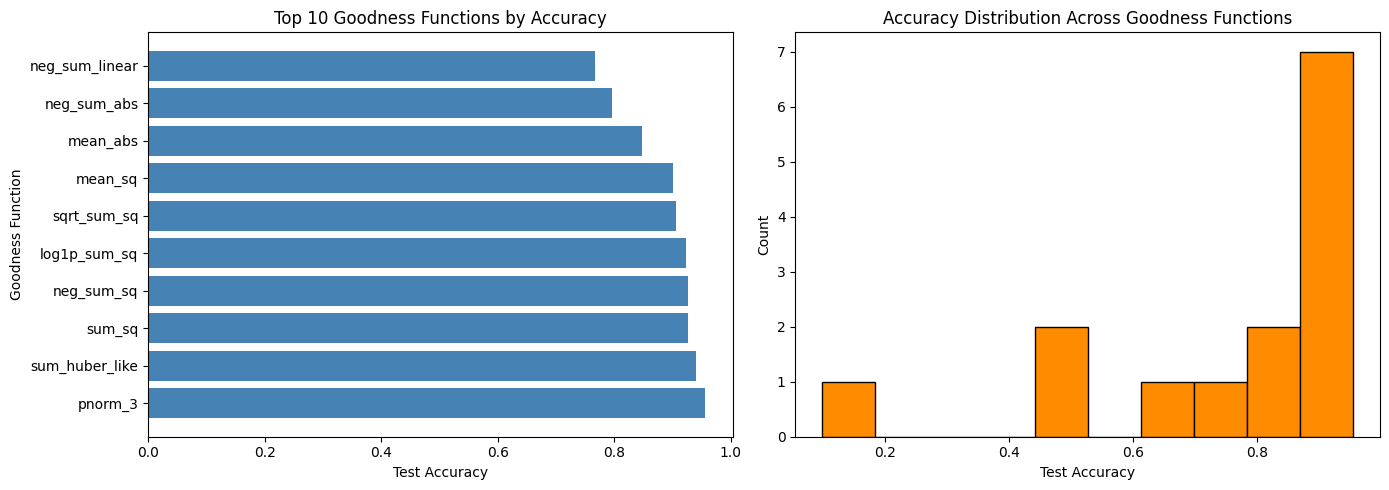

,goodness,test_accuracy,test_error,train_loss
0,pnorm_3,0.9554,0.0446,0.506840
1,sum_huber_like,0.9399,0.0601,0.915776
2,sum_sq,0.9263,0.0737,0.557461
3,neg_sum_sq,0.9259,0.0741,0.451928
4,log1p_sum_sq,0.9223,0.0777,0.648728
5,sqrt_sum_sq,0.9059,0.0941,0.673295
6,mean_sq,0.9012,0.0988,1.157837
7,mean_abs,0.8481,0.1519,1.306145
8,neg_sum_abs,0.7965,0.2035,1.053865
9,neg_sum_linear,0.7659,0.2341,1.110900


In [11]:
import matplotlib.pyplot as plt

plot_df = obj1_results.copy()
top10 = plot_df.nsmallest(10, "test_error").sort_values("test_error", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top10["goodness"], top10["test_accuracy"], color="steelblue")
axes[0].set_title("Top 10 Goodness Functions by Accuracy")
axes[0].set_xlabel("Test Accuracy")
axes[0].set_ylabel("Goodness Function")

axes[1].hist(plot_df["test_accuracy"], bins=10, color="darkorange", edgecolor="black")
axes[1].set_title("Accuracy Distribution Across Goodness Functions")
axes[1].set_xlabel("Test Accuracy")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

plot_df[["goodness", "test_accuracy", "test_error", "train_loss"]].head(10)

## Visualization and Analysis

The plots below show which goodness functions perform best and how spread out the results are.